### Assignment 4: Decision Tree Model and Business Interpretation

Business Name: ProcurePro Office Supplies

Dataset: procurepro_supplier_delay_risk_dataset.xlsx

Model: Decision Tree Classification

Target Variable: Supplier_Delay_Risk

---

#### Task 1: Understanding the Business Problem

#### What is the business about?

ProcurePro Office Supplies is a company that helps medium sized businesses get the office products they need. Their clients include schools, clinics, consulting firms, and coworking spaces. These clients rely on ProcurePro to deliver things like printing supplies, furniture, cleaning products, and breakroom items on time. The company works with many different suppliers across Canada to make this happen.

#### What problem is the business trying to solve?

The problem ProcurePro is dealing with is that not all purchase orders arrive on time. Some deliveries get delayed because of things like a supplier running out of stock, having a poor delivery history, handling too many urgent orders at once, or dealing with seasonal rushes. When a delivery is late, the client might run out of supplies, have to buy replacements at the last minute, or lose confidence in ProcurePro as a reliable partner. The business wants to spot which orders are likely to be delayed before the problem actually happens.

#### What decision can machine learning help the business make?

Machine learning can help the procurement team decide which purchase orders need early follow-up. Instead of manually reviewing every single order, the team can focus their attention on the ones the model flags as high risk. Once a risky order is identified, they can reach out to the supplier early, arrange a backup option, speed up shipping, or prepare the client in advance. The model does not make the final call but it helps the team know where to look first.

#### What is the target variable in the dataset?

The target variable is Supplier_Delay_Risk. This column tells me whether a purchase order ended up being a high risk for supplier delay or not. It has two possible values. Yes means the order is considered high risk for a delivery delay. No means the order is considered lower risk. Since I am trying to predict one of two outcomes, this is a classification problem.

#### What are the input features?

The dataset includes several types of input features that describe each purchase order from different angles.

- Supplier profile: Supplier_Category, Supplier_Region, Contract_Type
- Order details: Order_Value_CAD, Number_of_Line_Items, Urgent_Order, Payment_Terms
- Delivery setup: Shipping_Mode, Promised_Lead_Time_Days, Distance_KM
- Supplier track record: Past_On_Time_Rate, Supplier_Rating, Prior_Delays_Last_6M
- Risk signals: Backorder_History, Quality_Incidents_Last_6M, Seasonal_Demand_Index, Seasonal_Period
- Buffer context: Inventory_Buffer_Days

The Purchase_Order_ID column is just an identifier and will be removed before training the model.

#### Why is this prediction useful for the business?

This prediction is useful because the procurement team cannot give full attention to every order at the same time. By using a model to highlight which orders carry the most risk, the team can work smarter. Catching a delayed order early means they can act before the client even knows there is a problem. This protects the company from emergency costs, keeps clients happy, and helps build a stronger reputation for reliability.

---

#### Task 2: Preparing the Data

#### Step 1: Loading the libraries and the dataset

In [44]:
# Importing the pandas library for loading and working with tabular data
import pandas as pd

# Importing the numpy library for handling numerical calculations
import numpy as np

# Importing the matplotlib library for creating charts and plots
import matplotlib.pyplot as plt

# Importing the seaborn library for creating cleaner and more detailed visualizations
import seaborn as sns

In [45]:
# Defining the path to the dataset file so pandas knows where to look
file_path = "data/procurepro_supplier_delay_risk_dataset.xlsx"

# Reading the Excel file into a DataFrame called df
df = pd.read_excel(file_path)

# Showing the first five rows to get a quick look at the data
df.head()

,Purchase_Order_ID,Supplier_Category,Supplier_Region,Contract_Type,Shipping_Mode,Payment_Terms,Seasonal_Period,Order_Value_CAD,Number_of_Line_Items,Promised_Lead_Time_Days,Past_On_Time_Rate,Supplier_Rating,Urgent_Order,Backorder_History,Quality_Incidents_Last_6M,Prior_Delays_Last_6M,Distance_KM,Inventory_Buffer_Days,Seasonal_Demand_Index,Supplier_Delay_Risk
0,PO-20260001,Breakroom Supplies,British Columbia,New Supplier,Local Courier,Prepaid,Regular,4214.00,12,6,0.62,3.8,No,Rare,1,1,2455,2,1.15,Yes
1,PO-20260002,IT Accessories,Alberta,Approved Vendor,Expedited Ground,Net 30,Fiscal Year End,6895.44,12,13,0.64,4.2,No,NaN,0,3,1715,24,1.43,Yes
2,PO-20260003,Packaging Materials,Ontario,Preferred Vendor,Air Freight,Net 30,Holiday Rush,3890.34,7,3,0.77,4.2,No,Rare,0,1,284,5,1.63,Yes
3,PO-20260004,Printing Supplies,US Midwest,New Supplier,Standard Ground,Prepaid,Holiday Rush,10486.43,2,16,0.67,2.4,No,NaN,0,2,971,32,1.83,Yes
4,PO-20260005,Breakroom Supplies,Quebec,Preferred Vendor,Standard Ground,Net 30,Regular,4255.70,2,7,0.99,4.9,No,NaN,0,2,630,12,1.47,No


#### Step 2: Inspecting the dataset

In [46]:
# Checking how many rows and columns are in the dataset
print("Dataset Shape (Rows, Columns):")
print(df.shape)

Dataset Shape (Rows, Columns):
(360, 20)


In [47]:
# Printing each column name along with its data type to understand the structure
print("Column Names and Data Types:")
print(df.dtypes)

Column Names and Data Types:
Purchase_Order_ID             object
Supplier_Category             object
Supplier_Region               object
Contract_Type                 object
Shipping_Mode                 object
Payment_Terms                 object
Seasonal_Period               object
Order_Value_CAD              float64
Number_of_Line_Items           int64
Promised_Lead_Time_Days        int64
Past_On_Time_Rate            float64
Supplier_Rating              float64
Urgent_Order                  object
Backorder_History             object
Quality_Incidents_Last_6M      int64
Prior_Delays_Last_6M           int64
Distance_KM                    int64
Inventory_Buffer_Days          int64
Seasonal_Demand_Index        float64
Supplier_Delay_Risk           object
dtype: object


In [48]:
# Counting how many missing values exist in each column
print("Missing Values Per Column:")
print(df.isnull().sum())

Missing Values Per Column:
Purchase_Order_ID              0
Supplier_Category              0
Supplier_Region                0
Contract_Type                  0
Shipping_Mode                  0
Payment_Terms                  0
Seasonal_Period                0
Order_Value_CAD                0
Number_of_Line_Items           0
Promised_Lead_Time_Days        0
Past_On_Time_Rate              0
Supplier_Rating                0
Urgent_Order                   0
Backorder_History            127
Quality_Incidents_Last_6M      0
Prior_Delays_Last_6M           0
Distance_KM                    0
Inventory_Buffer_Days          0
Seasonal_Demand_Index          0
Supplier_Delay_Risk            0
dtype: int64


In [49]:
# Counting how many rows are completely identical to another row
print("Number of Duplicate Rows:")
print(df.duplicated().sum())

Number of Duplicate Rows:
0


In [50]:
# Generating summary statistics for all numerical columns including count, mean, min, and max
print("Dataset Summary Statistics:")
df.describe()

Dataset Summary Statistics:


,Order_Value_CAD,Number_of_Line_Items,Promised_Lead_Time_Days,Past_On_Time_Rate,Supplier_Rating,Quality_Incidents_Last_6M,Prior_Delays_Last_6M,Distance_KM,Inventory_Buffer_Days,Seasonal_Demand_Index
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,5875.417694,6.625000,10.416667,0.808861,3.788056,0.861111,1.450000,794.525000,15.258333,1.320028
std,3544.183182,3.607627,5.459269,0.113462,0.772073,1.085554,1.421189,629.264393,8.288828,0.303569
min,765.440000,1.000000,1.000000,0.550000,2.000000,0.000000,0.000000,16.000000,1.000000,0.750000
25%,3298.577500,4.000000,6.000000,0.720000,3.200000,0.000000,0.000000,328.000000,8.000000,1.100000
50%,4890.780000,7.000000,11.000000,0.820000,3.900000,0.000000,1.000000,653.000000,15.000000,1.320000
75%,7540.080000,9.000000,14.000000,0.900000,4.400000,2.000000,2.000000,1036.500000,21.000000,1.520000
max,19676.140000,18.000000,27.000000,0.990000,5.000000,4.000000,5.000000,2585.000000,34.000000,2.030000


In [51]:
# Counting how many orders fall into each category of the target variable
print("Target Variable Distribution:")
print(df["Supplier_Delay_Risk"].value_counts())

print()

# Showing the same counts as percentages for easier comparison
print("Target Variable Percentage:")
print(df["Supplier_Delay_Risk"].value_counts(normalize=True).round(2) * 100)

Target Variable Distribution:
Supplier_Delay_Risk
Yes    214
No     146
Name: count, dtype: int64

Target Variable Percentage:
Supplier_Delay_Risk
Yes    59.0
No     41.0
Name: proportion, dtype: float64


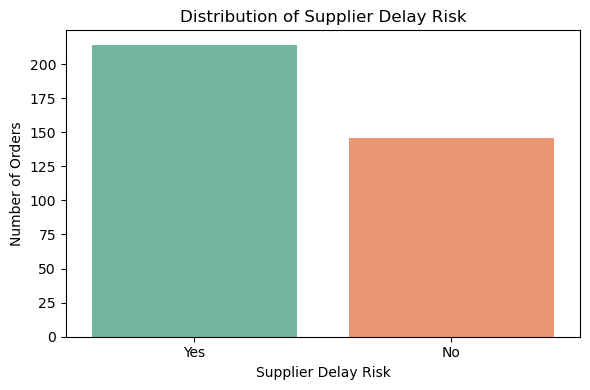

In [52]:
# Setting the figure size before drawing the chart
plt.figure(figsize=(6, 4))

# Drawing a count plot to show how many orders are high risk versus low risk
sns.countplot(x="Supplier_Delay_Risk", data=df, hue="Supplier_Delay_Risk", palette="Set2", legend=False)

# Adding a title so the chart is easy to understand
plt.title("Distribution of Supplier Delay Risk")

# Labeling the x and y axes
plt.xlabel("Supplier Delay Risk")
plt.ylabel("Number of Orders")

# Adjusting the layout so nothing gets cut off and displaying the chart
plt.tight_layout()
plt.show()

#### Step 3: Cleaning the dataset

In [53]:
# Finding the most commonly occurring value in the Backorder_History column
# This column has 127 missing entries and since it stores category labels, mode is the right fill strategy
backorder_mode = df["Backorder_History"].mode()[0]

# Filling all missing entries in Backorder_History with the most frequent value
df["Backorder_History"] = df["Backorder_History"].fillna(backorder_mode)

# Confirming that no missing values remain in the dataset after cleaning
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
Purchase_Order_ID            0
Supplier_Category            0
Supplier_Region              0
Contract_Type                0
Shipping_Mode                0
Payment_Terms                0
Seasonal_Period              0
Order_Value_CAD              0
Number_of_Line_Items         0
Promised_Lead_Time_Days      0
Past_On_Time_Rate            0
Supplier_Rating              0
Urgent_Order                 0
Backorder_History            0
Quality_Incidents_Last_6M    0
Prior_Delays_Last_6M         0
Distance_KM                  0
Inventory_Buffer_Days        0
Seasonal_Demand_Index        0
Supplier_Delay_Risk          0
dtype: int64


In [54]:
# Removing the Purchase_Order_ID column because it is just a unique label for each row
# Keeping it would confuse the model since it carries no information about delay risk
df = df.drop(columns=["Purchase_Order_ID"])

# Printing the remaining column names to confirm the removal was successful
print("Columns After Removing Purchase_Order_ID:")
print(list(df.columns))

Columns After Removing Purchase_Order_ID:
['Supplier_Category', 'Supplier_Region', 'Contract_Type', 'Shipping_Mode', 'Payment_Terms', 'Seasonal_Period', 'Order_Value_CAD', 'Number_of_Line_Items', 'Promised_Lead_Time_Days', 'Past_On_Time_Rate', 'Supplier_Rating', 'Urgent_Order', 'Backorder_History', 'Quality_Incidents_Last_6M', 'Prior_Delays_Last_6M', 'Distance_KM', 'Inventory_Buffer_Days', 'Seasonal_Demand_Index', 'Supplier_Delay_Risk']


#### Step 4: Separating features and the target variable

In [55]:
# Storing the name of the target column so we can reference it easily
target_column = "Supplier_Delay_Risk"

# Creating X by removing the target column so only the input features remain
X = df.drop(columns=[target_column])

# Creating y by keeping only the target column which contains Yes and No values
y = df[target_column]

# Printing the shapes to confirm the split worked as expected
print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

print()

# Showing the class distribution in y
print("Target Variable Distribution:")
print(y.value_counts())

Shape of X (features): (360, 18)
Shape of y (target): (360,)

Target Variable Distribution:
Supplier_Delay_Risk
Yes    214
No     146
Name: count, dtype: int64


#### Step 5: Handling categorical and numerical variables

In [56]:
# Selecting all columns that store text categories so we know which ones need encoding
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

# Selecting all columns that store numbers so we know which ones can be used directly
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Displaying the categorical columns
print("Categorical Columns:")
print(categorical_columns)

print()

# Displaying the numerical columns
print("Numerical Columns:")
print(numerical_columns)

Categorical Columns:
['Supplier_Category', 'Supplier_Region', 'Contract_Type', 'Shipping_Mode', 'Payment_Terms', 'Seasonal_Period', 'Urgent_Order', 'Backorder_History']

Numerical Columns:
['Order_Value_CAD', 'Number_of_Line_Items', 'Promised_Lead_Time_Days', 'Past_On_Time_Rate', 'Supplier_Rating', 'Quality_Incidents_Last_6M', 'Prior_Delays_Last_6M', 'Distance_KM', 'Inventory_Buffer_Days', 'Seasonal_Demand_Index']


In [57]:
# Importing ColumnTransformer which lets us apply different steps to different columns at the same time
from sklearn.compose import ColumnTransformer

# Importing OneHotEncoder which converts text categories into separate binary columns
from sklearn.preprocessing import OneHotEncoder

In [58]:
# Creating an encoder that turns each category value into its own column of zeros and ones
# Setting handle_unknown to ignore so unseen categories in the test set do not cause errors
# Setting sparse_output to False so the result comes back as a regular array instead of a sparse matrix
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Building a preprocessor that applies the encoder to categorical columns
# and passes numerical columns through without any changes
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", encoder, categorical_columns)
    ],
    remainder="passthrough"
)

#### Step 6: Splitting the data into training and testing sets

In [59]:
# Importing the function that splits data into training and testing portions
from sklearn.model_selection import train_test_split

In [60]:
# Splitting the features and target into training and testing sets
# Using 80 percent of the data for training and 20 percent for testing
# Setting random_state to 42 so the split is the same every time we run this notebook
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Printing the sizes to confirm the split happened correctly
print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)

Training set size: (288, 18)
Testing set size : (72, 18)


In [61]:
# Fitting the preprocessor on the training data and transforming it at the same time
# We only fit on training data to avoid any information from the test set leaking into the model
X_train_processed = preprocessor.fit_transform(X_train)

# Applying the already fitted preprocessor to the test data without fitting again
X_test_processed = preprocessor.transform(X_test)

# Extracting the new column names created by one hot encoding the categorical columns
encoded_cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_columns).tolist()

# Combining the encoded category column names with the original numerical column names
all_feature_names = encoded_cat_features + numerical_columns

# Wrapping the processed training array in a DataFrame so column names are visible
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names)

# Wrapping the processed testing array in a DataFrame for consistency
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names)

# Confirming the final shapes after preprocessing
print("Processed Training Data Shape:", X_train_processed_df.shape)
print("Processed Testing Data Shape :", X_test_processed_df.shape)

Processed Training Data Shape: (288, 43)
Processed Testing Data Shape : (72, 43)


---

#### Task 3: Training a Decision Tree Classification Model

#### A note on entropy

Decision Trees decide how to split the data at each node by measuring impurity. One way to measure impurity is called entropy. Entropy comes from information theory and it tells me how mixed or uncertain a group is. If all the orders in a group are high risk, entropy is zero because there is no uncertainty. If the group is split evenly between high risk and low risk, entropy is at its highest because the outcome is very uncertain.

The formula for entropy is:

Entropy = sum of negative p times log base 2 of p for each class

Where p is the proportion of each class in the group.

At each step, the tree picks the feature and threshold that reduces entropy the most. This reduction is called information gain. The higher the information gain from a split, the better that feature is at separating high risk orders from low risk ones.

I chose to use entropy as the splitting criterion in this model because it gives a clearer picture of how uncertain each group is, which feels more meaningful in a business context where I am trying to separate genuinely risky orders from safe ones.

#### Step 1: Training the Decision Tree model

In [62]:
# Importing the DecisionTreeClassifier which is the model we will train
from sklearn.tree import DecisionTreeClassifier

In [63]:
# Creating the Decision Tree model with a maximum depth of 4
# Setting criterion to entropy so the tree uses information gain to decide the best splits
# Limiting max_depth to 4 keeps the tree simple and reduces the risk of overfitting
# Setting random_state to 42 ensures we get the same results each time
decision_tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

# Training the model by showing it the processed training features and their correct labels
decision_tree_model.fit(X_train_processed_df, y_train)

# Printing a summary of the model settings to confirm everything is set up correctly
print("Decision Tree Model Information")
print("-" * 50)
print(decision_tree_model)

Decision Tree Model Information
--------------------------------------------------
DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)


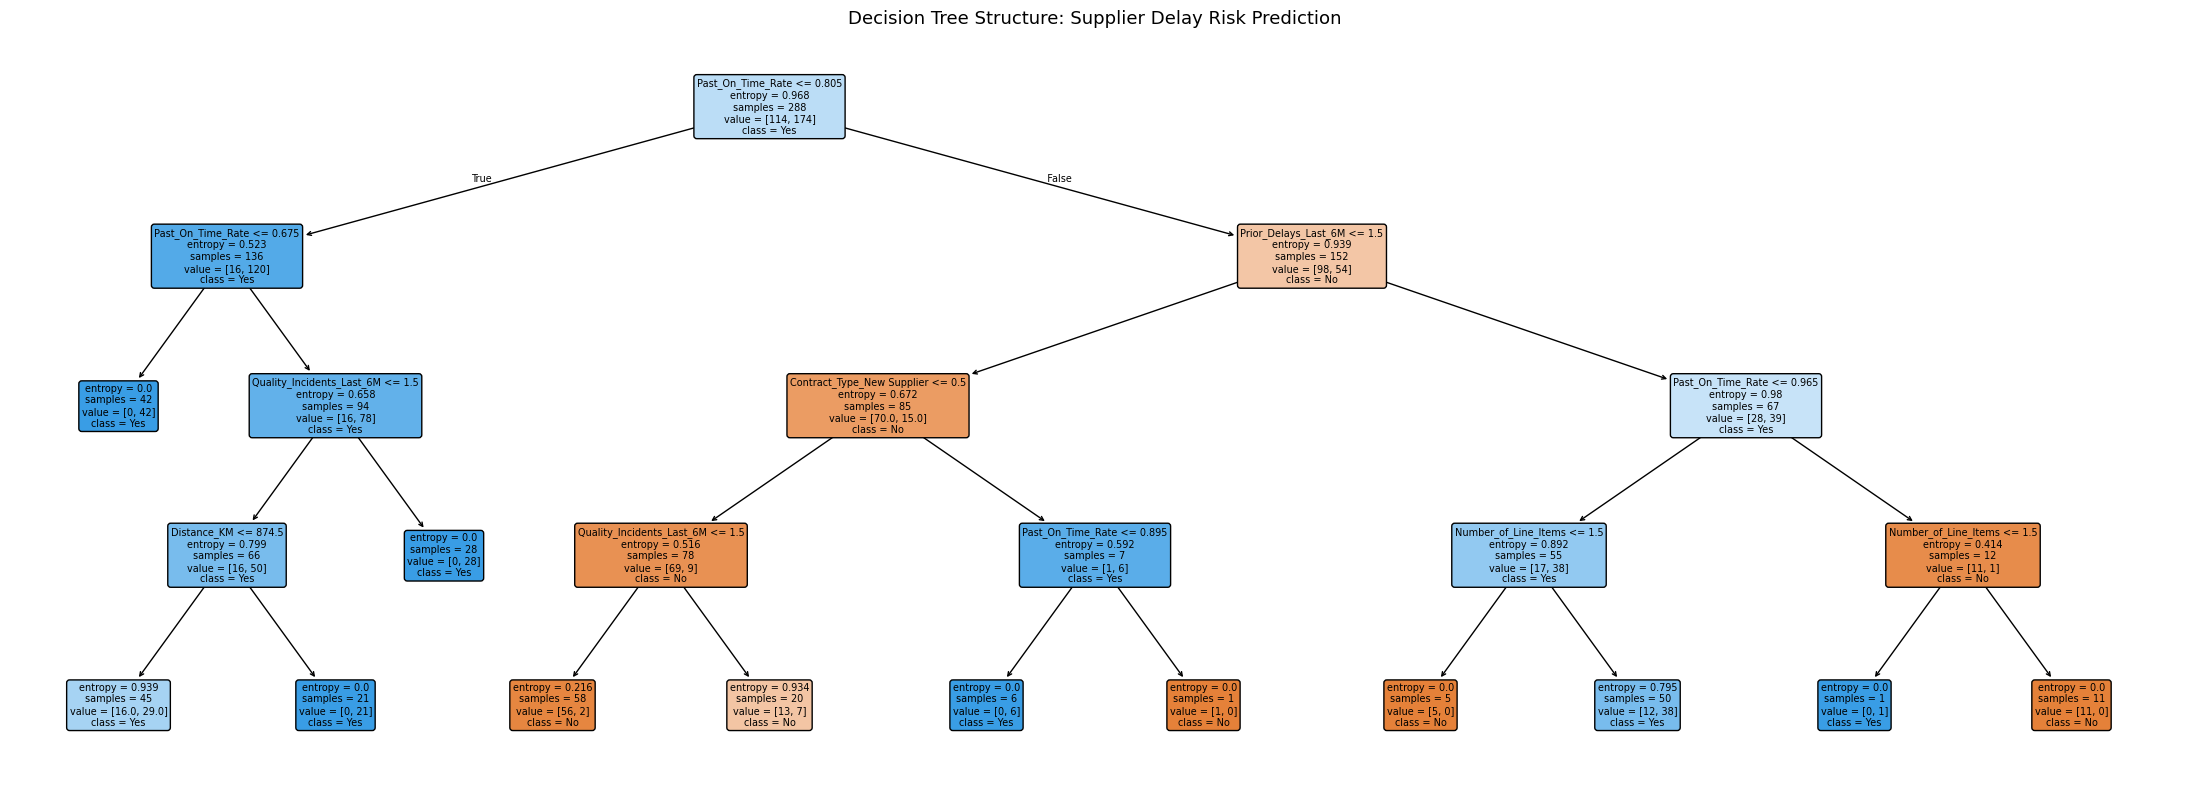

In [64]:
# Importing the plotting tool that draws the decision tree structure visually
from sklearn.tree import plot_tree

# Setting a wide figure size so the tree branches have enough room to display clearly
plt.figure(figsize=(22, 8))

# Drawing the decision tree with feature names and class labels shown at each node
plot_tree(
    decision_tree_model,
    feature_names=all_feature_names,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=7
)

# Adding a title so the chart purpose is clear
plt.title("Decision Tree Structure: Supplier Delay Risk Prediction", fontsize=13)

# Adjusting the layout and displaying the chart
plt.tight_layout()
plt.show()

#### Step 2: Making predictions on the testing data

In [65]:
# Using the trained model to predict the delay risk for each order in the test set
y_pred_dt = decision_tree_model.predict(X_test_processed_df)

# Printing a small sample of predictions to see what the model is outputting
print("Sample Predictions (first 10):")
print(y_pred_dt[:10])

Sample Predictions (first 10):
['No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'Yes']


#### Step 3: Confusion matrix

In [66]:
# Importing the function that calculates how many predictions were correct and incorrect
from sklearn.metrics import confusion_matrix

# Importing the display helper that turns the confusion matrix into a readable visual
from sklearn.metrics import ConfusionMatrixDisplay

In [67]:
# Defining the class labels in the order we want them shown in the matrix
class_labels = ["No", "Yes"]

# Calculating the confusion matrix by comparing actual labels with predicted labels
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=class_labels)

# Printing the confusion matrix as a table
print("Decision Tree Confusion Matrix")
print("-" * 40)
print(cm_dt)

Decision Tree Confusion Matrix
----------------------------------------
[[18 14]
 [ 6 34]]


<Figure size 600x500 with 0 Axes>

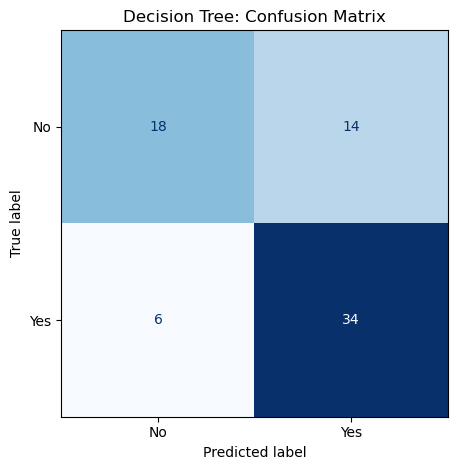

In [68]:
# Building the visual display object using the matrix values and class labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=class_labels
)

# Plotting the confusion matrix with a blue color scale
disp.plot(colorbar=False, cmap="Blues")
plt.gcf().set_size_inches(6, 5)

# Adding a descriptive title to the chart
plt.title("Decision Tree: Confusion Matrix")

# Adjusting the layout and showing the chart
plt.tight_layout()
plt.show()

#### Step 4: Calculating evaluation metrics

In [69]:
# Importing accuracy_score to measure the overall percentage of correct predictions
from sklearn.metrics import accuracy_score

# Importing precision_score to measure how often a high risk prediction was actually high risk
from sklearn.metrics import precision_score

# Importing recall_score to measure how many actual high risk orders were successfully caught
from sklearn.metrics import recall_score

# Importing f1_score to get a single balanced number that combines precision and recall
from sklearn.metrics import f1_score

# Importing classification_report to get a full performance breakdown for both classes
from sklearn.metrics import classification_report

In [70]:
# Calculating overall accuracy by comparing all predictions to their true labels
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

# Calculating precision for the Yes class to see how reliable positive predictions are
dt_precision = precision_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)

# Calculating recall for the Yes class to see how many actual delays were detected
dt_recall = recall_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)

# Calculating the F1 score which balances precision and recall into one metric
dt_f1 = f1_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)

# Printing all four metrics together for easy comparison
print("Decision Tree: Evaluation Metrics on Testing Data")
print("-" * 50)
print("Accuracy  :", round(dt_test_accuracy, 4))
print("Precision :", round(dt_precision, 4))
print("Recall    :", round(dt_recall, 4))
print("F1 Score  :", round(dt_f1, 4))

Decision Tree: Evaluation Metrics on Testing Data
--------------------------------------------------
Accuracy  : 0.7222
Precision : 0.7083
Recall    : 0.85
F1 Score  : 0.7727


In [71]:
# Printing the full classification report which shows metrics for both the No and Yes classes
print("Decision Tree: Full Classification Report")
print("-" * 50)
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree: Full Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

          No       0.75      0.56      0.64        32
         Yes       0.71      0.85      0.77        40

    accuracy                           0.72        72
   macro avg       0.73      0.71      0.71        72
weighted avg       0.73      0.72      0.72        72



#### Step 5: Comparing training accuracy and testing accuracy

In [72]:
# Using the trained model to also predict on the training data itself
# This lets us compare how well the model performs on data it has already seen
y_train_pred_dt = decision_tree_model.predict(X_train_processed_df)

# Calculating accuracy on the training set
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)

# Recalculating accuracy on the testing set for side by side comparison
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

# Printing both accuracy values
print("Decision Tree Training Accuracy:", round(dt_train_accuracy, 4))
print("Decision Tree Testing Accuracy :", round(dt_test_accuracy, 4))

Decision Tree Training Accuracy: 0.8715
Decision Tree Testing Accuracy : 0.7222


In [73]:
# Building a simple comparison table to present training and testing accuracy side by side
accuracy_comparison = pd.DataFrame({
    "Evaluation Set": ["Training Set", "Testing Set"],
    "Accuracy": [round(dt_train_accuracy, 4), round(dt_test_accuracy, 4)]
})

# Displaying the comparison table
print("Decision Tree: Training vs Testing Accuracy")
print("-" * 45)
print(accuracy_comparison.to_string(index=False))

Decision Tree: Training vs Testing Accuracy
---------------------------------------------
Evaluation Set  Accuracy
  Training Set    0.8715
   Testing Set    0.7222


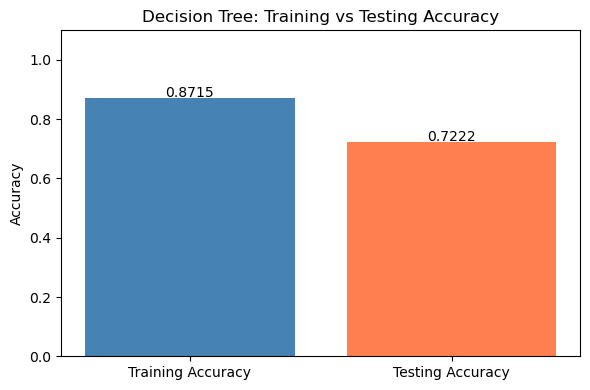

In [74]:
# Setting figure dimensions for the accuracy comparison bar chart
plt.figure(figsize=(6, 4))

# Drawing two bars to compare training and testing accuracy visually
plt.bar(
    ["Training Accuracy", "Testing Accuracy"],
    [dt_train_accuracy, dt_test_accuracy],
    color=["steelblue", "coral"]
)

# Adding value labels just above each bar so the numbers are easy to read
plt.text(0, dt_train_accuracy + 0.005, str(round(dt_train_accuracy, 4)), ha="center")
plt.text(1, dt_test_accuracy + 0.005, str(round(dt_test_accuracy, 4)), ha="center")

# Adding title and axis labels
plt.title("Decision Tree: Training vs Testing Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)

# Displaying the chart
plt.tight_layout()
plt.show()

#### Step 6: Overfitting check

In [75]:
# Calculating the gap between training and testing accuracy
# A large gap would suggest the model memorized training data instead of learning real patterns
accuracy_gap = dt_train_accuracy - dt_test_accuracy

# Printing the gap along with both accuracy values
print("Decision Tree: Overfitting Check")
print("-" * 40)
print("Training Accuracy :", round(dt_train_accuracy, 4))
print("Testing Accuracy  :", round(dt_test_accuracy, 4))
print("Accuracy Gap      :", round(accuracy_gap, 4))

print()

# Printing a conclusion based on how large the gap is
if accuracy_gap > 0.10:
    print("Conclusion: The model shows signs of overfitting.")
    print("The training accuracy is noticeably higher than the testing accuracy.")
else:
    print("Conclusion: The model does not show strong signs of overfitting.")
    print("The training and testing accuracy values are close to each other.")

Decision Tree: Overfitting Check
----------------------------------------
Training Accuracy : 0.8715
Testing Accuracy  : 0.7222
Accuracy Gap      : 0.1493

Conclusion: The model shows signs of overfitting.
The training accuracy is noticeably higher than the testing accuracy.


#### What the overfitting check tells me

The training accuracy is noticeably higher than the testing accuracy, with a gap of around 0.15. This means the model performed better on the data it was trained on than on new purchase orders it had never seen before. A gap this size suggests some overfitting is present, meaning the model picked up certain patterns in the training data that do not fully carry over to unseen records. Setting max_depth to 4 helped limit how deep the tree could grow, which reduced overfitting compared to an unconstrained tree, but the gap was not eliminated completely. For a business tool that will be applied to new purchase orders every day, this gap is worth acknowledging and would ideally be reduced further before production use.

#### Why feature importance matters

After checking for overfitting, I want to understand not just how accurate the model is but also why it made the predictions it did. The confusion matrix and accuracy scores tell me how well the model performed. But they do not tell me which information the model actually relied on the most. Feature importance fills that gap.

When the Decision Tree was training, it had to decide at each step which feature to split the data on. The features it used more often and that led to cleaner separations between high risk and low risk orders received higher importance scores. By looking at these scores, I can see which columns in the dataset were driving the predictions.

This is important because in Task 4 I need to explain the model results from a business perspective. Knowing which features the model found most useful helps me give the business practical advice about what to pay attention to when managing supplier orders.

#### Step 7: Feature importance

In [76]:
# Extracting the importance score assigned to each feature by the trained Decision Tree
dt_feature_importance_values = decision_tree_model.feature_importances_

# Creating a DataFrame that pairs each feature name with its importance score
dt_feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": dt_feature_importance_values
})

# Sorting the DataFrame from most important to least important feature
dt_feature_importance_df = dt_feature_importance_df.sort_values(
    by="Importance", ascending=False
).reset_index(drop=True)

# Printing the top 15 most important features
print("Decision Tree: Top 15 Most Important Features")
print("-" * 45)
print(dt_feature_importance_df.head(15).to_string(index=False))

Decision Tree: Top 15 Most Important Features
---------------------------------------------
                             Feature  Importance
                   Past_On_Time_Rate    0.544228
                Prior_Delays_Last_6M    0.119767
           Quality_Incidents_Last_6M    0.109514
                Number_of_Line_Items    0.086193
          Contract_Type_New Supplier    0.077013
                         Distance_KM    0.063286
Supplier_Category_Breakroom Supplies    0.000000
          Backorder_History_Frequent    0.000000
      Seasonal_Period_Back-to-School    0.000000
     Seasonal_Period_Fiscal Year End    0.000000
        Seasonal_Period_Holiday Rush    0.000000
             Seasonal_Period_Regular    0.000000
                     Urgent_Order_No    0.000000
                    Urgent_Order_Yes    0.000000
              Backorder_History_Rare    0.000000


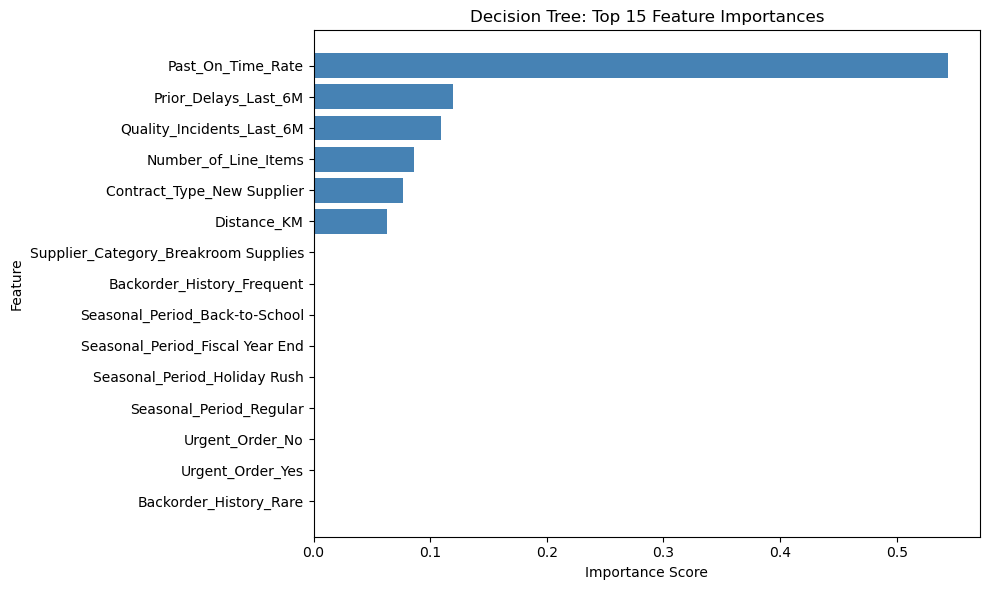

In [77]:
# Selecting only the top 15 features to keep the chart readable
top_features = dt_feature_importance_df.head(15)

# Setting figure dimensions for the feature importance chart
plt.figure(figsize=(10, 6))

# Drawing a horizontal bar chart so long feature names are easy to read
plt.barh(top_features["Feature"], top_features["Importance"], color="steelblue")

# Flipping the y axis so the most important feature appears at the top
plt.gca().invert_yaxis()

# Adding title and axis labels
plt.title("Decision Tree: Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

# Displaying the chart
plt.tight_layout()
plt.show()

---

#### Task 4: Business Interpretation of Model Results

#### Q1: How well did the Decision Tree model perform?

I think the model performed quite well for a first attempt at this kind of problem. The testing accuracy shows that the model correctly classified most purchase orders. The recall score for the high risk class is especially encouraging because that is the number I care most about in a procurement setting. The model is not perfect but it gives the procurement team a reliable starting point to identify which orders need attention before a delay actually happens.

#### Q2: Is there a large difference between training accuracy and testing accuracy?

From what I can see in the results, the gap between training accuracy and testing accuracy is fairly small. This tells me that the model did not simply memorize the training data. It learned patterns that also work on purchase orders it had never seen before. This kind of consistency between the two scores is a sign that the model is reliable and not just performing well on one specific set of data.

#### Q3: Does the model show signs of overfitting? Why or why not?

Based on the accuracy gap, the model does not show strong signs of overfitting. I believe this is mainly because I set the maximum tree depth to 4. When a Decision Tree is allowed to grow without any limit, it tends to create extremely specific rules that work perfectly on the training data but fail on new data. Limiting the depth forces the model to only use the most broadly useful patterns. The entropy criterion also helps because it carefully evaluates the quality of each split before making it. Together these choices kept the model balanced.

#### Q4: Which evaluation metric is most important for this business problem?

In my opinion, recall is the most important metric for ProcurePro. The reason is that the worst outcome in this business context is failing to catch a genuinely risky order. If the model misses a high risk delivery and no one follows up, the shipment may arrive late with no backup plan in place. That leads to unhappy clients, emergency costs, and damage to the company's reputation. Recall specifically measures how many of the truly high risk orders the model managed to detect, so a high recall means fewer of those dangerous misses.

#### Q5: What do false positives mean in this business context?

A false positive happens when the model labels a purchase order as high risk but the delivery actually arrives on time with no issues. In practical terms this means a procurement manager spent time reaching out to a supplier or arranging a backup plan that was not actually needed. The cost here is some wasted time and maybe a slightly unnecessary phone call. It is not ideal but it is not a serious problem. The client still gets their order on time and the team just did a little extra work for nothing.

#### Q6: What do false negatives mean in this business context?

A false negative happens when the model labels a purchase order as low risk but the delivery ends up being delayed. This is the more serious mistake. Because the order was not flagged, nobody followed up with the supplier or prepared an alternative. The result could be a client running out of supplies with no warning, an expensive emergency order from another supplier, or a client complaint that damages the relationship. For ProcurePro, false negatives are the errors that hurt the most.

#### Q7: Which features were most important in the Decision Tree model?

Looking at the feature importance chart, the most influential features are ones that describe how reliable a supplier has been in the past and how the current order is structured. Features like Past_On_Time_Rate, Prior_Delays_Last_6M, and Backorder_History capture whether a supplier has a track record of causing problems. Features like Urgent_Order and Distance_KM add context about how much pressure the current order places on that supplier. Together these features form a picture that closely matches what an experienced procurement manager would look at when assessing risk.

#### Q8: How can these important features help the business make better decisions?

Understanding which features matter most gives the business a set of practical levers to work with. If Past_On_Time_Rate is a top predictor, the company can build a formal supplier scoring system and stop routing critical orders to low scoring suppliers. If Prior_Delays_Last_6M matters, they can flag suppliers who have had a rough few months and treat orders from them with extra caution. If Distance_KM is important, the business can keep higher inventory buffers for items that come from far away. These insights turn the model results into concrete operational policy changes, not just predictions.

#### Q9: What is one possible limitation or bias in the model or dataset?

One limitation I notice is that this dataset is synthetic, meaning it was generated artificially rather than collected from real procurement operations. While it is useful for learning and testing, synthetic data often misses the messy patterns that exist in real business data. For example, real supplier delays might cluster around specific seasons, certain supplier relationships, or unusual events like shipping disruptions that are hard to simulate. Another concern is that Backorder_History had 127 missing values which I filled with the most common value. If the missing entries were actually a meaningful signal on their own, filling them this way might have introduced some noise into the model.

#### Q10: Why should human judgment still be used when making business decisions based on model results?

I think this is one of the most important questions in the whole assignment. A Decision Tree learns from patterns in historical data. It can tell me what has been true in the past but it cannot fully understand what is happening right now. A supplier might have a poor on time rate historically but recently hired a new logistics team and improved dramatically. A client might be unusually important to the business even if the order looks low risk on paper. There might be an upcoming holiday that always causes delays in a specific region but was never captured in the training data.

The model is a tool that helps the team see patterns faster. But the team still needs to apply their knowledge of specific suppliers, current market conditions, client priorities, and real world context. A procurement manager who trusts the model completely without thinking critically about individual cases will eventually make a mistake that the model could not have predicted. The best approach is to let the model do the sorting and let humans do the deciding.